In [1]:
import numpy as np
import matplotlib.pyplot as plt

grid_size = 10

In [2]:
robot_pos = (0, 0)
goal_pos = (9, 9)

obstacles = [
    (2, 2), (2, 3), (2, 4),
    (5, 5), (5, 6), (5, 7),
    (7, 1), (7, 2), (7, 3),
]

In [3]:
def build_grid(robot_pos, goal_pos, obstacles, size=grid_size):
    grid = np.zeros((size, size))

    for obs in obstacles:
        grid[obs] = 1

    grid[goal_pos] = 2
    grid[robot_pos] = 3

    return grid

In [4]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "black", "limegreen", "royalblue"])

def render_grid(grid, title="Robot World"):
    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=3)
    plt.title(title)
    plt.xticks(range(grid_size))
    plt.yticks(range(grid_size))
    plt.grid(color="gray", linewidth=0.5)
    plt.gca().set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    plt.gca().set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    plt.grid(which="minor", color="gray", linewidth=0.5)
    plt.show()

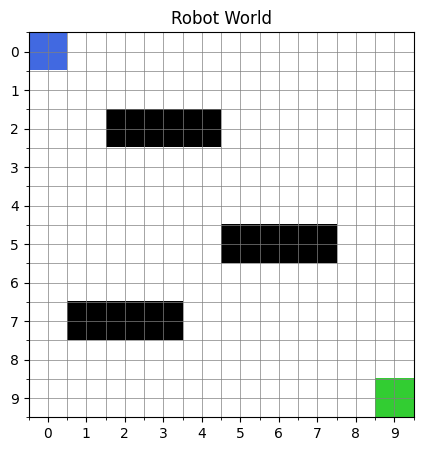

In [5]:
grid = build_grid(robot_pos, goal_pos, obstacles)
render_grid(grid)

In [6]:
ACTIONS = {
    "up":    (-1, 0),
    "down":  (1, 0),
    "left":  (0, -1),
    "right": (0, 1),
}

In [7]:
def step(robot_pos, action, goal_pos, obstacles, size=grid_size):
    dr, dc = ACTIONS[action]
    new_pos = (robot_pos[0] + dr, robot_pos[1] + dc)

    out_of_bounds = not (0 <= new_pos[0] < size and 0 <= new_pos[1] < size)

    if out_of_bounds:
        return robot_pos, -5, False

    if new_pos in obstacles:
        return robot_pos, -5, False

    if new_pos == goal_pos:
        return new_pos, 10, True

    return new_pos, -1, False

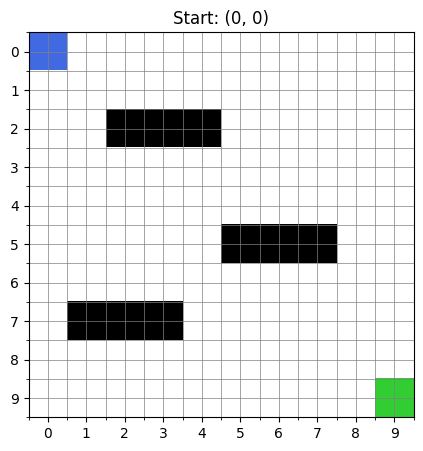

In [8]:
robot_pos = (0, 0)
render_grid(build_grid(robot_pos, goal_pos, obstacles), title=f"Start: {robot_pos}")

New position: (0, 1) | reward: -1 | done: False


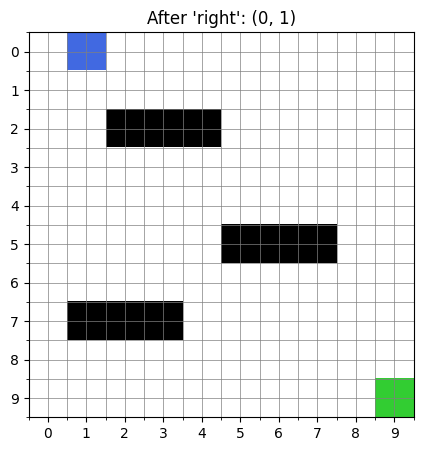

In [9]:
robot_pos, reward, done = step(robot_pos, "right", goal_pos, obstacles)
print("New position:", robot_pos, "| reward:", reward, "| done:", done)
render_grid(build_grid(robot_pos, goal_pos, obstacles), title=f"After 'right': {robot_pos}")

New position: (1, 1) | reward: -1 | done: False


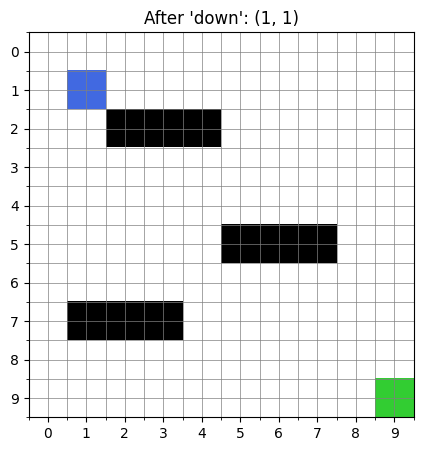

In [10]:
robot_pos, reward, done = step(robot_pos, "down", goal_pos, obstacles)
print("New position:", robot_pos, "| reward:", reward, "| done:", done)
render_grid(build_grid(robot_pos, goal_pos, obstacles), title=f"After 'down': {robot_pos}")

Reached the goal at (9, 9)! Final reward: 10


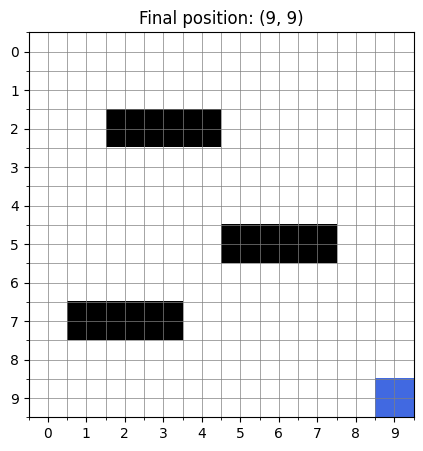

In [11]:
robot_pos = (0, 0)
manual_actions = ["right"] * 9 + ["down"] * 9

for a in manual_actions:
    robot_pos, reward, done = step(robot_pos, a, goal_pos, obstacles)
    if done:
        print(f"Reached the goal at {robot_pos}! Final reward: {reward}")
        break

render_grid(build_grid(robot_pos, goal_pos, obstacles), title=f"Final position: {robot_pos}")

In [12]:
import random

In [13]:
ACTION_NAMES = list(ACTIONS.keys())

In [14]:
q_table = np.zeros((grid_size, grid_size, len(ACTIONS)))

In [15]:
q_table[0, 0]

array([0., 0., 0., 0.])

In [16]:
def choose_action(state, q_table, epsilon):
    if random.random() < epsilon:
        return random.choice(ACTION_NAMES)
    row, col = state
    q_values = q_table[row, col]
    max_q = np.max(q_values)
    best_indices = np.flatnonzero(q_values == max_q)  # all indices tied for the max
    best_index = random.choice(best_indices)            # pick randomly among ties
    return ACTION_NAMES[best_index]

In [17]:
ALPHA = 0.1
GAMMA = 0.9

def update_q(q_table, state, action, reward, next_state):
    row, col = state
    action_index = ACTION_NAMES.index(action)

    next_row, next_col = next_state
    best_next_q = np.max(q_table[next_row, next_col])

    current_q = q_table[row, col, action_index]
    target = reward + GAMMA * best_next_q
    q_table[row, col, action_index] = current_q + ALPHA * (target - current_q)

    return q_table

In [18]:
q_table = np.zeros((grid_size, grid_size, len(ACTIONS)))
robot_pos = (0, 0)
epsilon = 1.0
max_steps = 50


for t in range(max_steps):
    action = choose_action(robot_pos, q_table, epsilon)
    new_pos, reward, done = step(robot_pos, action, goal_pos, obstacles)
    q_table = update_q(q_table, robot_pos, action, reward, new_pos)

    print(f"Step {t}: {robot_pos} --{action}--> {new_pos} | reward={reward} | done={done}")

    robot_pos = new_pos
    if done:
        print("Reached the goal!")
        break

Step 0: (0, 0) --left--> (0, 0) | reward=-5 | done=False
Step 1: (0, 0) --right--> (0, 1) | reward=-1 | done=False
Step 2: (0, 1) --down--> (1, 1) | reward=-1 | done=False
Step 3: (1, 1) --down--> (2, 1) | reward=-1 | done=False
Step 4: (2, 1) --right--> (2, 1) | reward=-5 | done=False
Step 5: (2, 1) --up--> (1, 1) | reward=-1 | done=False
Step 6: (1, 1) --left--> (1, 0) | reward=-1 | done=False
Step 7: (1, 0) --down--> (2, 0) | reward=-1 | done=False
Step 8: (2, 0) --up--> (1, 0) | reward=-1 | done=False
Step 9: (1, 0) --down--> (2, 0) | reward=-1 | done=False
Step 10: (2, 0) --down--> (3, 0) | reward=-1 | done=False
Step 11: (3, 0) --right--> (3, 1) | reward=-1 | done=False
Step 12: (3, 1) --up--> (2, 1) | reward=-1 | done=False
Step 13: (2, 1) --right--> (2, 1) | reward=-5 | done=False
Step 14: (2, 1) --left--> (2, 0) | reward=-1 | done=False
Step 15: (2, 0) --down--> (3, 0) | reward=-1 | done=False
Step 16: (3, 0) --left--> (3, 0) | reward=-5 | done=False
Step 17: (3, 0) --down--> 

In [19]:
nonzero_cells = np.argwhere(np.any(q_table != 0, axis=2))

In [20]:
import time
from IPython.display import clear_output

In [21]:
EPISODES = 500
MAX_STEPS = 100
epsilon = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.05

preview_eps = 1.0
preview_values = []
for _ in range(EPISODES):
    preview_values.append(preview_eps)
    preview_eps = max(EPSILON_MIN, preview_eps * EPSILON_DECAY)

In [22]:
q_table = np.zeros((grid_size, grid_size, len(ACTIONS)))
epsilon = 1.0
episode_rewards = []

for episode in range(EPISODES):
    robot_pos = (0, 0)
    total_reward = 0

    for t in range(MAX_STEPS):
        action = choose_action(robot_pos, q_table, epsilon)
        new_pos, reward, done = step(robot_pos, action, goal_pos, obstacles)
        q_table = update_q(q_table, robot_pos, action, reward, new_pos)

        robot_pos = new_pos
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if episode % 50 == 0:
        print(f"Episode {episode}: total_reward={total_reward}, epsilon={epsilon:.3f}")

Episode 0: total_reward=-136, epsilon=0.995
Episode 50: total_reward=-124, epsilon=0.774
Episode 100: total_reward=-137, epsilon=0.603
Episode 150: total_reward=-32, epsilon=0.469
Episode 200: total_reward=-39, epsilon=0.365
Episode 250: total_reward=-36, epsilon=0.284
Episode 300: total_reward=-15, epsilon=0.221
Episode 350: total_reward=-26, epsilon=0.172
Episode 400: total_reward=-16, epsilon=0.134
Episode 450: total_reward=-7, epsilon=0.104


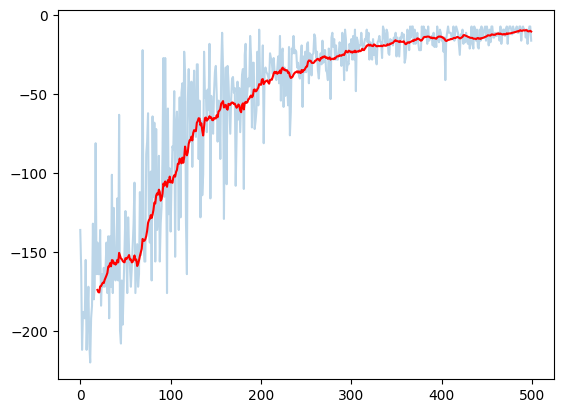

In [23]:
plt.plot(episode_rewards, alpha=0.3, label="Raw reward per episode")

window = 20
rolling_avg = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
plt.plot(range(window - 1, EPISODES), rolling_avg, color="red", label=f"{window}-episode rolling average")

In [24]:
robot_pos = (0, 0)
path = [robot_pos]

for t in range(MAX_STEPS):
    action = choose_action(robot_pos, q_table, epsilon=0.0)
    robot_pos, reward, done = step(robot_pos, action, goal_pos, obstacles)
    path.append(robot_pos)
    if done:
        break

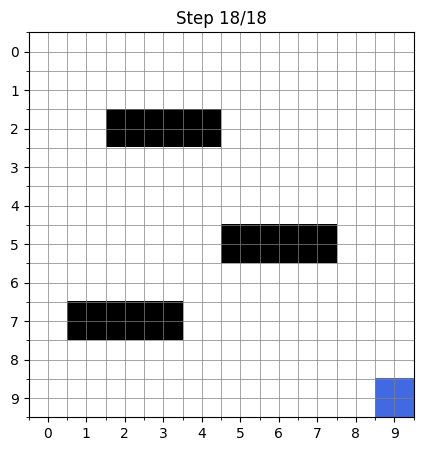

In [25]:
for i, pos in enumerate(path):
    clear_output(wait=True)
    render_grid(build_grid(pos, goal_pos, obstacles), title=f"Step {i}/{len(path)-1}")
    time.sleep(0.3)

In [26]:
value_map = np.max(q_table, axis=2)

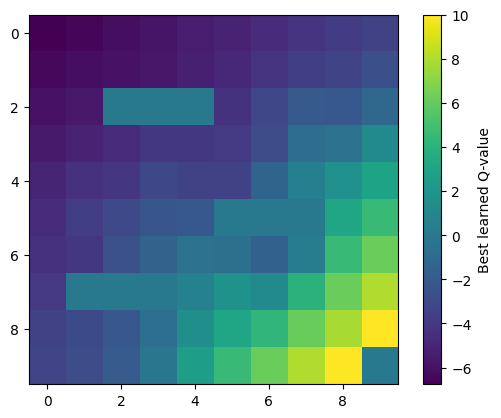

In [27]:
im = plt.imshow(value_map, cmap="viridis")
plt.colorbar(im, label="Best learned Q-value")

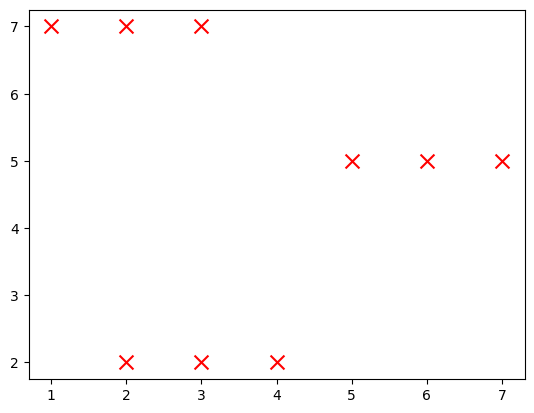

In [28]:
for obs in obstacles:
    plt.scatter(obs[1], obs[0], marker="x", color="red", s=100)

In [29]:
ARROW_VECTORS = {
    "up":    (0, -0.3),
    "down":  (0, 0.3),
    "left":  (-0.3, 0),
    "right": (0.3, 0),
}

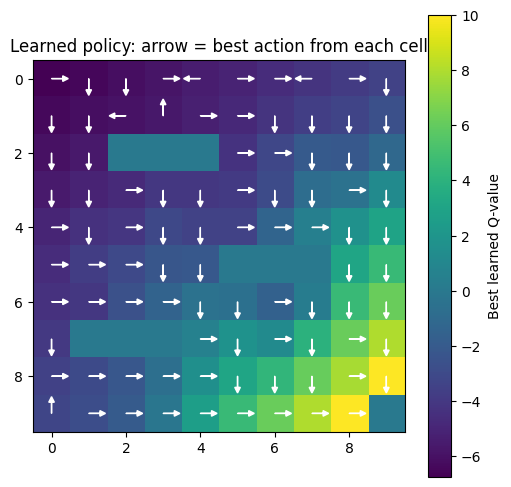

In [30]:
plt.figure(figsize=(6, 6))
im = plt.imshow(value_map, cmap="viridis")
plt.colorbar(im, label="Best learned Q-value")
plt.title("Learned policy: arrow = best action from each cell")

for row in range(grid_size):
    for col in range(grid_size):
        if (row, col) in obstacles or (row, col) == goal_pos:
            continue
        best_action_index = np.argmax(q_table[row, col])
        best_action = ACTION_NAMES[best_action_index]
        dx, dy = ARROW_VECTORS[best_action]
        plt.arrow(col, row, dx, dy, head_width=0.15, head_length=0.15, color="white")